### Numpy basics

1\. Find the row, column and overall means for the following matrix:

```python
m = np.arange(12).reshape((3,4))
```

In [2]:
# tipical alias for numpy is np
import numpy as np
# arange generate an array of int between 0 and 11, then shape it into an array of 3 arrays of 4 elements
# in numpy the first index select the row of the matrix, the second the column, but tecnically only rows are separated arrays
m = np.arange(12).reshape((3,4))
# the logic in the mean key axis is "which axis is changed when the sum is done?", 
# so axis=0, the default, gives the mean of the colums, because the first index is the one along which the sum is performed
# it makes more sense thinking vectorially as python is concived, the mean is made for each element of the row of multiple column vector by default
row_mean = np.mean( m, axis=1 )
column_mean = np.mean( m, axis=0 )
mean = np.mean( m )
print(m)
print("row_mean:", row_mean, "column_mean:", column_mean, "mean", mean )

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
row_mean: [1.5 5.5 9.5] column_mean: [4. 5. 6. 7.] mean 5.5


2\. Find the outer product of the following two vecotrs

```python
u = np.array([1,3,5,7])
v = np.array([2,4,6,8])
```

Do this in the following ways:

   * Using the function outer in numpy
   * Using a nested for loop or list comprehension
   * Using numpy broadcasting operatoins


In [3]:
# EXAM EXERCISE

# defining two vector using an initialization by a list
u = np.array([1,3,5,7])
v = np.array([2,4,6,8])

# outer product as defined by numpy
uv_outer = np.outer( u, v )
# using a list comprehension, an array (columns) of arrays (rows) made by the one element of the first vector for all elements of the second one
uv_loop = np.array([[i*j for i in v] for j in u])
# using the broadcast, reschaping u to be a 4 by 1 matrix, an array of arrays of one element, so each of those has to be broadcasted to be like v when multiplied
uv_broadcast = u.reshape(4,1) * v
print(uv_outer)
print(uv_loop)
print(uv_broadcast)
# using magic timeit to compute statistical time used for various methods
%timeit uv_outer = np.outer( u, v )
%timeit uv_loop = np.array([[i*j for i in v] for j in u])
%timeit uv_broadcast = u.reshape(4,1) * v

[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]
[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]
[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]
2.22 μs ± 20 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
6.23 μs ± 78.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
1.47 μs ± 1.69 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


3\. Create a 10 by 6 matrix of random uniform numbers. Set all rows with any entry less than 0.1 to be zero

Hint: Use the following numpy functions - np.random.random, np.any as well as Boolean indexing and the axis argument.

In [4]:
# a chosen alias for numpy random
import numpy.random as npr
npr.seed(42069)
# rand is a function to generate uniform distributed values between 0 and 1 (default) of shape given, here 10 by 6, same order required by numpy
random_matrix = npr.rand(10,6)
print(random_matrix)
# this returns a matrix with the same shape of random_matrix (operations are made element-wise) of True or False value
mask = ( random_matrix < 0.1 )
# this is a check over the rows (axis = 1, the check is done changing the second index) for any True, any returns True if at least one True is found in a array of bool
zero_rows = np.any( mask, axis=1 )
print(zero_rows)
#this works FOR SOME REASONS, here an array of True/False is given and acts like a mask:
# only the rows (index 0) for which the array value is True are touched, and they are set to 0.0, which itself is broadcasted to become a row-like array
random_matrix[zero_rows] = 0.0
print(random_matrix)

[[0.03050837 0.4194086  0.87769215 0.71350281 0.32398232 0.76532979]
 [0.24675681 0.9325032  0.3076937  0.89399192 0.01161114 0.30166537]
 [0.57473552 0.40037047 0.49660527 0.32682084 0.28948197 0.54827428]
 [0.08559335 0.03289536 0.1044298  0.04755629 0.74637658 0.39611861]
 [0.23910018 0.87511899 0.59568677 0.28027473 0.92865147 0.3962173 ]
 [0.45416509 0.90731638 0.61644611 0.42153713 0.4021603  0.17079612]
 [0.10476093 0.74393725 0.94502009 0.23595762 0.20072338 0.80879791]
 [0.57656414 0.57933503 0.15003907 0.97857361 0.48426815 0.81266531]
 [0.21142129 0.14967728 0.20387854 0.46167895 0.92645489 0.89815749]
 [0.03633572 0.16233204 0.8182529  0.72593908 0.74901527 0.06639882]]
[ True  True False  True False False False False False  True]
[[0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]
 [0.57473552 0.40037047 0.49660527 0.32682084 0.28948197 0.54827428]
 [0.         0.         0.         0.   

4\. Use np.linspace to create an array of 100 numbers between 0 and 2π (includsive).

  * Extract every 10th element using slice notation
  * Reverse the array using slice notation
  * Extract elements where the absolute difference between the sine and cosine functions evaluated at that element is less than 0.1
  * Make a plot showing the sin and cos functions and indicate where they are close

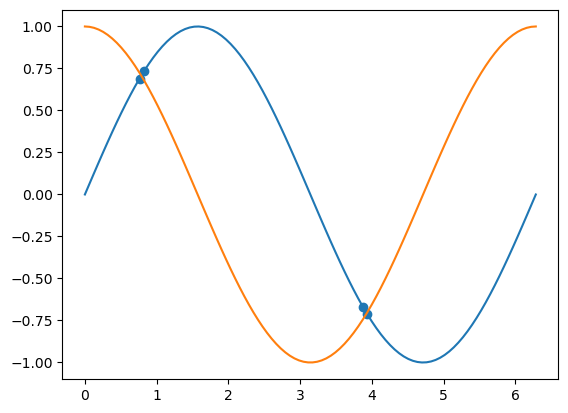

In [5]:
# EXAM EXERCISE

# the sintax of linspace is ( begin, end, number_of_samples )
circus = np.linspace(0., (2.0*np.pi), 100)
#print(circus)
# slicing circus, an array accessed through the index [], using [ starting : stop : steps ], 
# to start from the tenth element (index 9) until the end (space between :: is interpreted as end = -1) taking every 10 elements third argument
cs = circus[9::10]
#print(cs)
# reversr done moving backwards taking -1 as steps
sucric = circus[::-1]
#print(sucric)
# mask of circus, done using a function of circus itself: the element inside the [] generates a circus-like array of True/False, one for each resul of the evaluation over circus
cosincus = circus[np.abs(np.sin(circus)-np.cos(circus)) < 0.1]
#print(cosincus)

###PLOT???
import matplotlib.pyplot as plt
plt.plot(circus, np.sin(circus))
plt.plot(circus, np.cos(circus))
plt.scatter(cosincus, np.sin(cosincus))

5\. Create a matrix that shows the 10 by 10 multiplication table.

 * Find the trace of the matrix
 * Extract the anti-diagonal (this should be ```array([10, 18, 24, 28, 30, 30, 28, 24, 18, 10])```)
 * Extract the diagnoal offset by 1 upwards (this should be ```array([ 2,  6, 12, 20, 30, 42, 56, 72, 90])```)

In [6]:
# creating an array of 1 to 10 numbers
one_to_ten = np.arange(1,11)
# using outer to get the multiplication table (every number for every number)
OtT_multiplication_table = np.outer(one_to_ten,one_to_ten)
print(OtT_multiplication_table)
# numpy has trace... otherwise it can be done using slicing and list as np.sum(OtT_multiplication_table[np.arange(10), np.arange(10)])
print(np.trace(OtT_multiplication_table))
# here the slicing is done putting as indexes arrays, so that inside a tuple given by zip of those is used to select each element
# this is the table at index 0-9 connected to 9-0, as in (0,9), (1,8)...
print(OtT_multiplication_table[np.arange(0,10),np.arange(9,-1, -1)])
# this is the table at index 0-8 connected to 1-9, as in (0,1), (1,2)...
print(OtT_multiplication_table[np.arange(0,9),np.arange(1,10)])

[[  1   2   3   4   5   6   7   8   9  10]
 [  2   4   6   8  10  12  14  16  18  20]
 [  3   6   9  12  15  18  21  24  27  30]
 [  4   8  12  16  20  24  28  32  36  40]
 [  5  10  15  20  25  30  35  40  45  50]
 [  6  12  18  24  30  36  42  48  54  60]
 [  7  14  21  28  35  42  49  56  63  70]
 [  8  16  24  32  40  48  56  64  72  80]
 [  9  18  27  36  45  54  63  72  81  90]
 [ 10  20  30  40  50  60  70  80  90 100]]
385
[10 18 24 28 30 30 28 24 18 10]
[ 2  6 12 20 30 42 56 72 90]


6\. Use broadcasting to create a grid of distances

Route 66 crosses the following cities in the US: Chicago, Springfield, Saint-Louis, Tulsa, Oklahoma City, Amarillo, Santa Fe, Albuquerque, Flagstaff, Los Angeles
The corresponding positions in miles are: 0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448

  * Construct a 2D grid of distances among each city along Route 66
  * Convert that in km (those savages...)

In [7]:
# EXAM EXERCISE

# starting from city and distances array 
cities = np.array([ 'Chicago', 'Springfield', 'Saint-Louis', 'Tulsa', 'Oklahoma City', 'Amarillo', 'Santa Fe', 'Albuquerque', 'Flagstaff', 'Los Angeles' ])
distances = np.array([ 0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448 ])
# computing distances matrix as a reshape N,1 (matrix) of array(N) and then forcing broadcasting between (N,1) and (N,) causing an (N,N) matrix to be created
D2_distances = np.abs( distances.reshape(len(distances), 1) - distances )
print(cities)
print(D2_distances)
# using vectorial coding to perform the conversion operation element wise
km_dist = D2_distances * 1.60934
#print(km_dist)

['Chicago' 'Springfield' 'Saint-Louis' 'Tulsa' 'Oklahoma City' 'Amarillo'
 'Santa Fe' 'Albuquerque' 'Flagstaff' 'Los Angeles']
[[   0  198  303  736  871 1175 1475 1544 1913 2448]
 [ 198    0  105  538  673  977 1277 1346 1715 2250]
 [ 303  105    0  433  568  872 1172 1241 1610 2145]
 [ 736  538  433    0  135  439  739  808 1177 1712]
 [ 871  673  568  135    0  304  604  673 1042 1577]
 [1175  977  872  439  304    0  300  369  738 1273]
 [1475 1277 1172  739  604  300    0   69  438  973]
 [1544 1346 1241  808  673  369   69    0  369  904]
 [1913 1715 1610 1177 1042  738  438  369    0  535]
 [2448 2250 2145 1712 1577 1273  973  904  535    0]]


7\. Prime numbers sieve: compute the prime numbers in the 0-N (N=99 to start with) range with a sieve (mask).
  * Constract a shape (100,) boolean array, the mask
  * Identify the multiples of each number starting from 2 and set accordingly the corresponding mask element
  * Apply the mask to obtain an array of ordered prime numbers
  * Check the performances (timeit); how does it scale with N?
  * Implement the optimization suggested in the [sieve of Eratosthenes](https://en.wikipedia.org/wiki/Sieve_of_Eratosthenes)

In [73]:
# EXAM EXERCISE

# defining a basic function to return all prime numbers up to max_num
def primes(max_num) :
    # creating an array of all numbers from 0 to max_num (excluded)
    all_num = np.arange(max_num)
    # creating a mask, an array of True/False values
    # this one is made by the numpy conversion of a python list defined by a list comprehension
    # it negates any, a functon that is true if at least one element is true, in a list of boolean values
    # given by the modulo function of the i-esim number divided by all j-esim previous numbers
    # the cycle goes for i >1 (not considering 0 and 1) otherwise it returns False, 0 and 1 are not prime numbers
    # the syntax of a conditional list comprehension is either [ <statement> for i in <list> if <condition> ] or 
    # [ <statement> if <condition> else <different statement> for i in <list> ] if a if/else is needed (the position of if in reguard of for is fixed, and elif is not usable)
    mask = np.array( [ not np.any( np.array([ ((all_num[i]%all_num[j])==0) for j in range(2,i) ]) ) if i > 1 else False for i in range(len(all_num))] )
    # this returns a vew of the masked array of all numbers, remaining only prime
    prime_num = all_num[ mask ]
    return prime_num

# this is the real function of the Eratosthenes' sieve
def era_primes(max_num) : 
    # generating an array of all numbers up to max_num excluded
    all_num = np.arange(max_num)
    # starting with a mask of all True values, here full generates an array of shape (max_num,) (aka a np.array) of True values
    mask = np.full( (max_num,), True )
    # setting False the values corresponding to 0 and 1 (non-prime numbers)
    mask[0:2] = False
    # defining the numbers from which search multiples in the whole array (all non-prime are multiples of two smaller numbers, the biggest of the smaller in the couple is the square root):
    # casting as a int (it will be an index) the first integer (but as a float) before the square root of the max_number increased by one (to avoid 0)
    delta = int(np.floor(np.sqrt(max_num)) + 1)
    # cycling over the numbers between 1 and the 
    for i in range(2, delta) :
        # if the number is a prime, its mask is True
        if mask[i]:
            # assigning to j the value of the number at position i
            j = all_num[i]
            # starting from the first multiple of j, 2j
            j_n = 2*j
            # cycling all multiples of j until max is reached
            while( j_n < max_num ) :
                # setting multiples of j as false
                mask[j_n] = False
                # increasing j to the next multiple
                j_n += j
    # applying the mask to the vector of all numbers
    prime_num = all_num[ mask ]
    # returning the result
    return prime_num
    
# this is a failure of mine, trying to apply the optimization and getting a more costly result
def era_opt_primes(max_num, delta) :
    all_num = np.arange(max_num)
    mask = np.full( (max_num,), True )
    mask[0:2] = False
    first_delta = int(np.floor(np.sqrt(delta)) + 1)
    for i in range(2, first_delta) : 
        if mask[i]:
            j = all_num[i]
            j_n = 2*j
            while( j_n < delta ) :
                mask[j_n] = False
                j_n += j
    primes = np.array([ all_num[i] for i in range(2, delta) if mask[i]] )
    cycles = max_num//delta + 1
    for i in range(1, cycles) :
        n_min = delta*i
        n_max = delta*(i+1)
        if n_max > max_num : n_max = max_num
        mask_i = mask[ n_min : n_max ]
        for n in primes :
            offset = n - (n_min-1)%n -1
            for j in range( ( n_max - n_min ) // n +1 ) :
                if ( ( offset + n*j ) < ( n_max - n_min ) ) : mask_i[offset + n*j] = False
        primes_i = np.array([ all_num[i] for i in range(n_min, n_max) if mask[i]])
        primes = np.concatenate( (primes, primes_i) )
    primes = all_num[mask]
    return primes
        
        #concatenate
#%timeit primes(100)
#%timeit primes(200)
#%timeit primes(400)
#%timeit era_primes(100)
#%timeit era_primes(200)
#%timeit era_primes(400)
#print(primes(1000))
#print(era_primes(1000))
#print(era_opt_primes(1000, 37))
# timeit magic to see how the time scales with max number
%timeit era_primes(100)
%timeit era_primes(500)
%timeit era_primes(1000)
%timeit era_primes(5000)
%timeit era_primes(10000)
%timeit era_opt_primes(100, 10)
%timeit era_opt_primes(500, 23)
%timeit era_opt_primes(1000, 100)
%timeit era_opt_primes(5000, 223)
%timeit era_opt_primes(10000, 100)


14.1 μs ± 192 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
70.6 μs ± 180 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
148 μs ± 118 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
804 μs ± 4.65 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.74 ms ± 77.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
104 μs ± 1.01 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
596 μs ± 6.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
733 μs ± 11.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
4.91 ms ± 84.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
26.3 ms ± 394 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


**N.B. the following exercises are meant to be solved only if you are familiar with the numpy random library. If not you can skip them (postponed for one of the next exercise sessions)**


8\. Diffusion using random walk

Consider a simple random walk process: at each step in time, a walker jumps right or left (+1 or -1) with equal probability. The goal is to find the typical distance from the origin of a random walker after a given amount of time. 
To do that, let's simulate many walkers and create a 2D array with each walker as a raw and the actual time evolution as columns

  * Take 1000 walkers and let them walk for 200 steps
  * Use randint to create a 2D array of size walkers x steps with values -1 or 1
  * Build the actual walking distances for each walker (i.e. another 2D array "summing on each raw")
  * Take the square of that 2D array (elementwise)
  * Compute the mean of the squared distances at each step (i.e. the mean along the columns)
  * Plot the average distances (sqrt(distance\*\*2)) as a function of time (step)
  
Did you get what you expected?

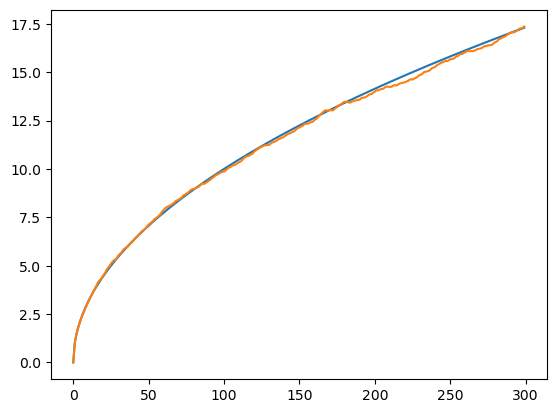

In [2]:
# EXAM EXERCISE

# importing numpy and numpy random with common aliases
import numpy as np
import numpy.random as npr
# step 1
#walkers = 1000
# defining number of walkers
walkers = 1500
#steps = 200
# defining number of steps
steps = 300
# step 2
# defining an array of random integers between 0 and 2 excluded (i.e. 0 or 1) of shape ( walkers, step ), a 2d matrix
walkerXsteps = npr.randint( 0, 2, size=( walkers, steps ) )
# traslation from [0,1] to  [-1,1] using a element-wise operation n*2-1
walkerXsteps = walkerXsteps*2 - 1
#print(walkerXsteps)

# >>>>>>>>> terrible way to do this
# step 3
# computing the walked distance as the sum of values for each walker (sum moving the value of index 1 corresponding to step number)
distances = np.sum(walkerXsteps, axis=1)
# step 4
# computing square distances as the second power element-wise
square_distances = distances * distances
# step 5
# doing everything in a list comprehension, then converting into a np array
# the lost has as element the square root of the sum of the square of the sum of the matrix,
# to which is applied the mask of True/False that allows to sum only the first i elements for each step i
mean_distances = np.array( [ np.sqrt( np.sum( np.power( np.sum( walkerXsteps, axis = 1, where=np.array([ [ False if ( k >= i ) else True for k in range( walkerXsteps.shape[ 1 ] )  ] for j in range( walkerXsteps.shape[ 0 ] ) ] ) ) , 2 ) / walkers ) ) for i in range( walkerXsteps.shape[ 1 ] ) ] )

# >>>>>>>>> better way to do this
# computing the walked distance as the sum of values for each walker (sum moving the value of index 1 corresponding to step number)
# this is done converting a list comprehension of partial sum for steps i in the range [0, N) where N is the second dimension of the matrix (shape[2])
# then the mask is applied using where to impose what to add from
# the mask is a np array of bool made by a list comprehension of False if the step number is grater than i, True otherwise
# the second list is needed to have multiple list for each walker
distances = np.array( [ np.sum( walkerXsteps, axis = 1, where=np.array([ [ False if ( k >= i ) else True for k in range( walkerXsteps.shape[ 1 ] )  ] for j in range( walkerXsteps.shape[ 0 ] ) ] ) ) for i in range( walkerXsteps.shape[ 1 ] ) ] )
# step 4
# computing square distances as the second power element-wise
square_distances = distances * distances
# step 5
# computing mean distances as the square root of the sum of normalized square of distances ( mean over the walkers, moving on axis 1)
mean_distances = np.sqrt( np.sum( square_distances / walkers, axis = 1) )

#where_to_sum = np.array([ [ False if ( k >= 5 ) else True for k in range( walkerXsteps.shape[ 1 ] )  ] for j in range( walkerXsteps.shape[ 0 ] ) ] )
#print(where_to_sum)
#dist = np.sum( walkerXsteps, axis = 1, where=where_to_sum )
#print(dist)
#dist_square = np.sum( np.power( dist, 2) / walkers )
#mean_distances = np.sqrt( dist_square )
# step 6
# plotting using matplotlib and using the theoretical result to compare
import matplotlib.pyplot as plt
# plt.plot([np.sqrt(4.*i*0.5*0.5) for i in range (steps) ])
plt.plot([np.sqrt(i) for i in range (steps) ])
plt.plot(mean_distances)

9\. Analyze a data file 
  * Download the population of hares, lynxes and carrots at the beginning of the last century.
    ```python
    ! wget https://www.dropbox.com/s/3vigxoqayo389uc/populations.txt
    ```

  * Check the content by looking within the file
  * Load the data (use an appropriate numpy method) into a 2D array
  * Create arrays out of the columns, the arrays being (in order): *year*, *hares*, *lynxes*, *carrots* 
  * Plot the 3 populations over the years
  * Compute the main statistical properties of the dataset (mean, std, correlations, etc.)
  * Which species has the highest population each year?

Do you feel there is some evident correlation here? [Studies](https://www.enr.gov.nt.ca/en/services/lynx/lynx-snowshoe-hare-cycle) tend to believe so.

In [28]:
# command to download file from web
! wget https://www.dropbox.com/s/3vigxoqayo389uc/populations.txt

--2024-11-15 16:49:53--  https://www.dropbox.com/s/3vigxoqayo389uc/populations.txt
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/qnkkslc4wt15bziu8c8do/populations.txt?rlkey=mxkget6g834glvegmf12yl2op [following]
--2024-11-15 16:49:54--  https://www.dropbox.com/scl/fi/qnkkslc4wt15bziu8c8do/populations.txt?rlkey=mxkget6g834glvegmf12yl2op
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc74aadf596feaf2f3e933281a3e.dl.dropboxusercontent.com/cd/0/inline/CeZyBbLNFFzokD5ijbelH261C3dTdKGVv630-0vw6ffnoRm27Qp4r8WIDJjcf9t2Keu-xqtxtUllGDBt9tUZRYwZsHluqjxTk2Wx49Pf0M2h3C7rktOgS5bIldcUHAT6eqg/file# [following]
--2024-11-15 16:49:55--  https://uc74aadf596feaf2f3e933281a3e.dl.dropboxusercontent.com/cd/0/inline/CeZyBbLNFF

Hares: mean=34081, std=20898, maximum=77400, minimum=7600, total data: 21
Lynxes: mean=20167, std=16255, maximum=59400, minimum=4000, total data: 21
Carrots: mean=42400, std=3323, maximum=48300, minimum=36700, total data: 21
Correlation between Hares and Lynxes = 0.07189
Correlation between Hares and Carrots = -0.01660
Correlation between Lynxes and Carrots = -0.68058
Correlation between Hares and Lynxes after two years = 0.92733
Correlation between Hares and Carrots after three years = -0.72979
(Most popolous species, year)
('Carrots', 1900.0)
('Carrots', 1901.0)
('Hares', 1902.0)
('Hares', 1903.0)
('Lynxes', 1904.0)
('Lynxes', 1905.0)
('Carrots', 1906.0)
('Carrots', 1907.0)
('Carrots', 1908.0)
('Carrots', 1909.0)
('Carrots', 1910.0)
('Carrots', 1911.0)
('Hares', 1912.0)
('Hares', 1913.0)
('Hares', 1914.0)
('Lynxes', 1915.0)
('Carrots', 1916.0)
('Carrots', 1917.0)
('Carrots', 1918.0)
('Carrots', 1919.0)
('Carrots', 1920.0)


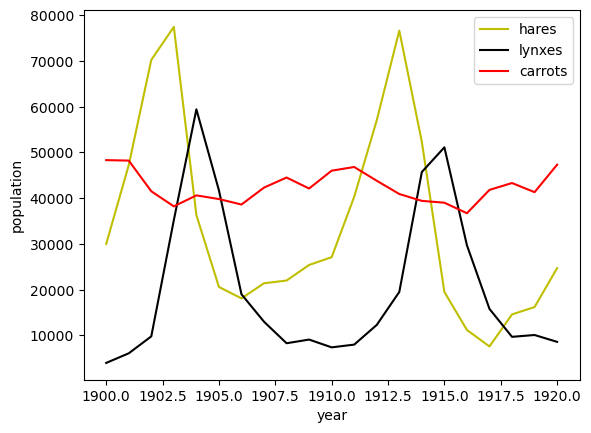

In [17]:
# EXAM EXERCISE

# import data from file using loadtxt
pop_data = np.loadtxt( 'populations.txt' )
# divide data
# using slicing to take data from a matrix into 4 arrays
# [ : , n ] allows to take all data along the first axis (row index) at fixed second axis value n (column index)
year = pop_data[ : , 0 ]
hares = pop_data[ : , 1 ]
lynxes = pop_data[ : , 2 ]
carrots = pop_data[ : , 3 ]
# plot data
# importi pyplot with usual alias
import matplotlib.pyplot as plt
# plotting each dataset (y) along years (x), with different colours ('y' for yellow, 'k' for black, 'r' for red) and correct lable
plt.plot( year, hares, 'y', label="hares" )
plt.plot( year, lynxes, 'k', label="lynxes" )
plt.plot( year, carrots, 'r', label="carrots" )
# adding legend automatic setted, and axes lables
plt.legend()
plt.xlabel('year')
plt.ylabel('population')
# analyze data
# printing outputs using the f"" format that allows usage of variables and computation
# using built-in numpy functions for mean, standard deviation, maximum, minimum and shape[0] for array lenght
print( f"Hares: mean={np.mean(hares):.0f}, std={np.std(hares):.0f}, maximum={np.max(hares):.0f}, minimum={np.min(hares):.0f}, total data: {hares.shape[0]}" )
print( f"Lynxes: mean={np.mean(lynxes):.0f}, std={np.std(lynxes):.0f}, maximum={np.max(lynxes):.0f}, minimum={np.min(lynxes):.0f}, total data: {lynxes.shape[0]}" )
print( f"Carrots: mean={np.mean(carrots):.0f}, std={np.std(carrots):.0f}, maximum={np.max(carrots):.0f}, minimum={np.min(carrots):.0f}, total data: {carrots.shape[0]}" )
# using same format to print correlation coefficient for couples of arrays 
# in this case the function produces a matrix, where diagonal elements are the autocorrelation and the elements outside are correlations
print( f"Correlation between Hares and Lynxes = {np.corrcoef(hares, lynxes)[ 1 , 0 ]:.5f}" )
print( f"Correlation between Hares and Carrots = {np.corrcoef(hares, carrots)[ 1 , 0 ]:.5f}" )
print( f"Correlation between Lynxes and Carrots = {np.corrcoef(lynxes, carrots)[ 1 , 0 ]:.5f}" )
# using slicing to compute correlation between different years (values of x): [from 0 to N-2) with [2 to N) for the first, [0:N-3) and [3:N) for the second 
print( f"Correlation between Hares and Lynxes after two years = {np.corrcoef(hares[:-2], lynxes[2:])[ 1 , 0 ]:.5f}" )
print( f"Correlation between Hares and Carrots after three years = {np.corrcoef(hares[:-3], carrots[3:])[ 1 , 0 ]:.5f}" )
# maximum population each year
# making a np array from a list comprehension of strings : using max to find the maximum in the triplet made from hares, lynxes and carrots numbers for each year, made with zip
# for each triplet i, if the maximum is the element in position 0 Hares are the most, otherwise if the maximum is in position 1 Lynxes are the most, otherwise are Carrots
max_pop = np.array([ 'Hares' if ( np.max( np.array( i ) ) == i[0] ) else ( 'Lynxes' if ( np.max( np.array( i ) ) == i[1] ) else 'Carrots' ) for i in zip( hares , lynxes , carrots ) ])
#print( [(year[i], max_pop[i]) for i in range(year.shape[0]) ] )
# printing species and year using zip to make them into a tuple
print('(Most popolous species, year)')
for i in zip(max_pop, year) : print( i )